In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2, norm, f, t
import warnings
warnings.filterwarnings('ignore')

def chi2_goodness_of_fit(data, dist, params, alpha=0.05):
    n = len(data)
    # Определим число интервалов по правилу Стёржесса
    m = int(np.log2(n)) + 1 
    if m < 5:
        m = 5
    # Гистограмма
    counts, bin_edges = np.histogram(data, bins=m)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    expected = []
    for i in range(m):
        p = dist.cdf(bin_edges[i+1], *params) - dist.cdf(bin_edges[i], *params)
        expected.append(n * p)
    expected = np.array(expected)

    while np.any(expected < 5):
        idx = np.argmin(expected)
        if idx == 0:
            expected[1] += expected[0]
            counts[1] += counts[0]
            expected = np.delete(expected, 0)
            counts = np.delete(counts, 0)
        elif idx == len(expected) - 1:
            expected[-2] += expected[-1]
            counts[-2] += counts[-1]
            expected = np.delete(expected, -1)
            counts = np.delete(counts, -1)
        else:
            if expected[idx-1] < expected[idx+1]:
                expected[idx-1] += expected[idx]
                counts[idx-1] += counts[idx]
                expected = np.delete(expected, idx)
                counts = np.delete(counts, idx)
            else:
                expected[idx+1] += expected[idx]
                counts[idx+1] += counts[idx]
                expected = np.delete(expected, idx)
                counts = np.delete(counts, idx)
    # Статистика хи-квадрат
    chi2_stat = np.sum((counts - expected)**2 / expected)
    df = len(expected) - 1 - len(params)
    p_value = 1 - chi2.cdf(chi2_stat, df)
    reject = p_value < alpha
    return chi2_stat, df, p_value, reject

np.random.seed(42)
n = 1000
k_vals = [1, 5, 10]

results_gauss = {}
for k in k_vals:
    X = np.random.uniform(0, 1, size=(n, k))
    Y = X.sum(axis=1)
    mu_hat = np.mean(Y)
    sigma_hat = np.std(Y, ddof=1)

    chi2_stat, df, p_val, reject = chi2_goodness_of_fit(Y, norm, (mu_hat, sigma_hat))

    qq = stats.probplot(Y, dist="norm", sparams=(mu_hat, sigma_hat))
    results_gauss[k] = {
        'data': Y,
        'mu': mu_hat,
        'sigma': sigma_hat,
        'chi2': chi2_stat,
        'df': df,
        'p': p_val,
        'reject': reject,
        'qq': qq
    }


In [3]:
print("Математическое ожидание для разных k:")
print([results_gauss[k]["mu"] for k in k_vals])
print("\nСтандартное отклонение для разных k:")
print([results_gauss[k]["sigma"] for k in k_vals])
print("\np-значения теста хи-квадрат для разных k:")
print([results_gauss[k]["p"] for k in k_vals])
print("\nРешения о гипотезе для разных k (True - отвергаем, False - не отвергаем):")
print([results_gauss[k]["reject"] for k in k_vals])

Математическое ожидание для разных k:
[np.float64(0.4902565533201336), np.float64(2.4923678908205567), np.float64(4.956837669086114)]

Стандартное отклонение для разных k:
[np.float64(0.292137361947486), np.float64(0.6343489962850289), np.float64(0.8759829359814735)]

p-значения теста хи-квадрат для разных k:
[np.float64(0.0), np.float64(0.10685882452024253), np.float64(0.44089086077969875)]

Решения о гипотезе для разных k (True - отвергаем, False - не отвергаем):
[np.True_, np.False_, np.False_]


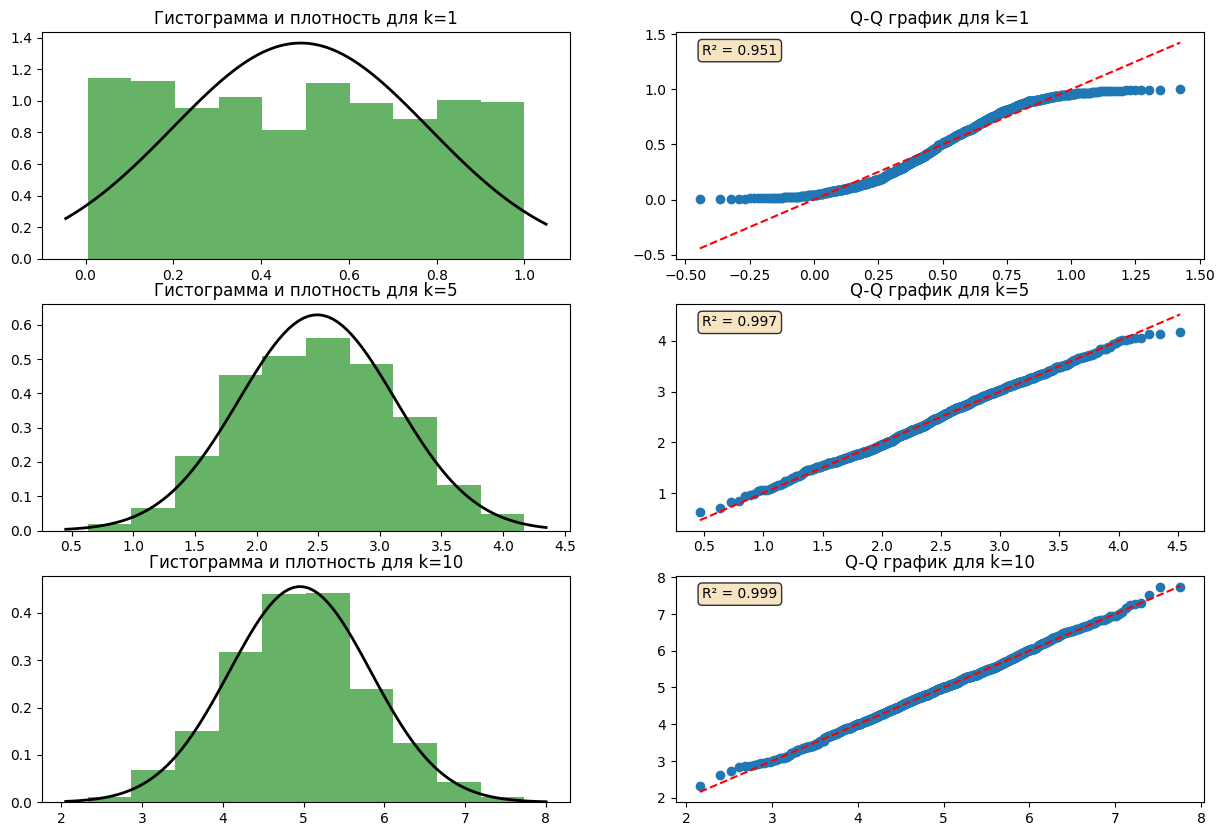

In [4]:
from sklearn.metrics import r2_score

figure = plt.figure(figsize=(15, 10))
for i, k in enumerate(k_vals):
    Y = results_gauss[k]['data']
    mu_hat = results_gauss[k]['mu']
    sigma_hat = results_gauss[k]['sigma']
    qq = results_gauss[k]['qq']
    m = int(np.log2(n)) + 1 
    ax1 = figure.add_subplot(3, 2, 2*i + 1)
    ax1.hist(Y, bins=m, density=True, alpha=0.6, color='g')
    xmin, xmax = ax1.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu_hat, sigma_hat)
    ax1.plot(x, p, 'k', linewidth=2)
    ax1.set_title(f'Гистограмма и плотность для k={k}')

    theoretical_q = np.array(qq[0][0])
    sample_q = np.array(qq[0][1])
    r2 = r2_score(theoretical_q, sample_q)

    ax2 = figure.add_subplot(3, 2, 2*i + 2)
    ax2.scatter(qq[0][0], qq[0][1])
    ax2.plot(qq[0][0], qq[0][0], 'r--')
    ax2.set_title(f'Q-Q график для k={k}')
    ax2.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax2.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

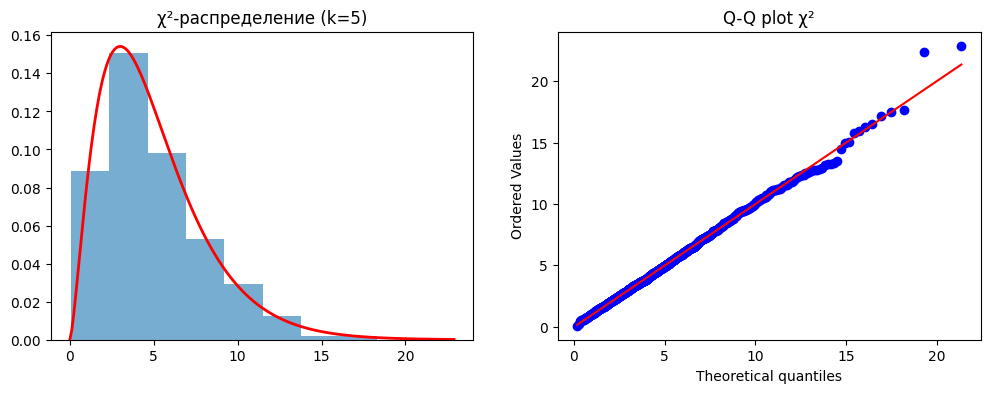

χ²-тест: статистика=10.40, p=0.319
H0 не отвергается
R2 = 0.9977003709634743


In [8]:
k_df = 5  # степени свободы
n = 1000
np.random.seed(42)
Z = np.random.normal(0, 1, size=(n, k_df))
chi2_sample = np.sum(Z**2, axis=1)

df_est = np.mean(chi2_sample)

m = int(np.log2(n)) + 1 # правило Стержесса

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(chi2_sample, bins=m, density=True, alpha=0.6)
x = np.linspace(0, chi2_sample.max(), 200)
plt.plot(x, stats.chi2.pdf(x, df=k_df), 'r-', lw=2)
plt.title(f'χ²-распределение (k={k_df})')
plt.subplot(1, 2, 2)
stats.probplot(chi2_sample, dist=stats.chi2, sparams=(k_df,), plot=plt)
plt.title('Q-Q plot χ²')
plt.show()


observed, bins = np.histogram(chi2_sample, bins=m)
expected = n * np.diff(stats.chi2.cdf(bins, df=k_df))
expected = expected * (observed.sum() / expected.sum())
chi2_stat, p = stats.chisquare(observed, expected)
print(f"χ²-тест: статистика={chi2_stat:.2f}, p={p:.3f}")
print(f"H0 {'отвергается' if p < 0.05 else 'не отвергается'}")
osm, osr = stats.probplot(chi2_sample, dist=stats.chi2, sparams=(k_df,), fit=False)
print(f"R2 = {r2_score(osm, osr)}")

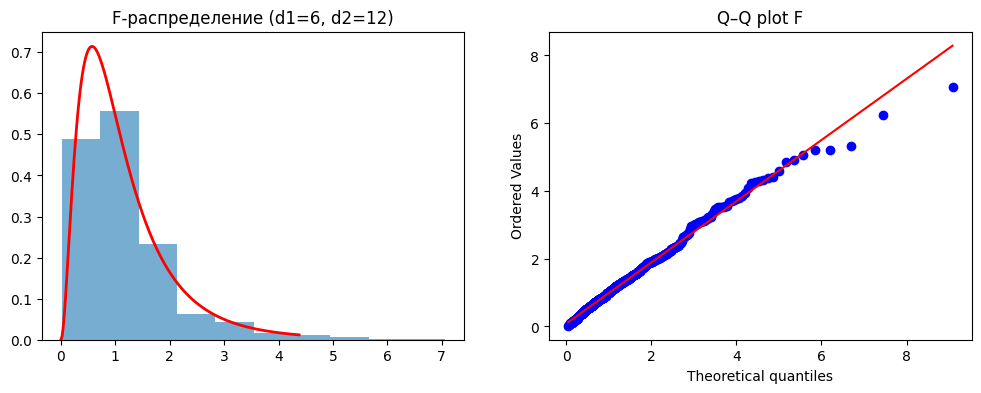

F-тест: χ²=13.18, p=0.155, H0 не отвергается
R2 = 0.9977003709634743


In [6]:
d1, d2 = 6, 12
n = 1000
np.random.seed(42)
U = np.sum(np.random.normal(0,1,size=(n,d1))**2, axis=1)
V = np.sum(np.random.normal(0,1,size=(n,d2))**2, axis=1)
m = int(np.log2(n)) + 1
F_sample = (U / d1) / (V / d2)

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(F_sample, bins=m, density=True, alpha=0.6)
x = np.linspace(0, np.percentile(F_sample, 99), 200)
plt.plot(x, stats.f.pdf(x, d1, d2), 'r-', lw=2)
plt.title(f'F-распределение (d1={d1}, d2={d2})')
plt.subplot(1, 2, 2)
stats.probplot(F_sample, dist=stats.f, sparams=(d1, d2), plot=plt)
plt.title('Q–Q plot F')
plt.show()

# χ²-тест
observed, bins = np.histogram(F_sample, bins=m)
expected = n * np.diff(stats.f.cdf(bins, d1, d2))
expected = expected * (observed.sum() / expected.sum())
chi2_stat, p = stats.chisquare(observed, expected)
print(f"F-тест: χ²={chi2_stat:.2f}, p={p:.3f}, H0 {'отвергается' if p < 0.05 else 'не отвергается'}")
osm, osr = stats.probplot(chi2_sample, dist=stats.chi2, sparams=(k_df,), fit=False)
print(f"R2 = {r2_score(osm, osr)}")

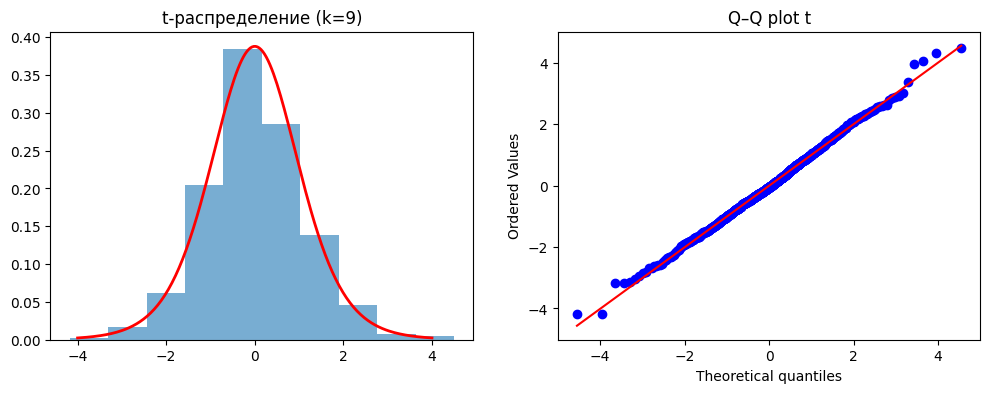

t-тест: χ²=7.87, p=0.547, H0 не отвергается


In [7]:
k = 9
n = 1000

Z = np.random.normal(0, 1, n)
V = np.sum(np.random.normal(0,1,size=(n,k))**2, axis=1)
T_sample = Z / np.sqrt(V / k)
m = int(np.log2(n)) + 1
# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(T_sample, bins=m, density=True, alpha=0.6)
x = np.linspace(-4, 4, 200)
plt.plot(x, stats.t.pdf(x, df=k), 'r-', lw=2)
plt.title(f't-распределение (k={k})')
plt.subplot(1, 2, 2)
stats.probplot(T_sample, dist=stats.t, sparams=(k,), plot=plt)
plt.title('Q–Q plot t')
plt.show()

# χ²-тест
observed, bins = np.histogram(T_sample, bins=m)
expected = n * np.diff(stats.t.cdf(bins, df=k))
expected = expected * (observed.sum() / expected.sum())
chi2_stat, p = stats.chisquare(observed, expected)
print(f"t-тест: χ²={chi2_stat:.2f}, p={p:.3f}, H0 {'отвергается' if p < 0.05 else 'не отвергается'}")